# Exploring Copernicus DEM elevation data

STAC url: 
- https://browser.stac.dataspace.copernicus.eu/collections/cop-dem-glo-30-dged-cog

Requirements: Get EO AWS S3 api key by registering account.

- https://documentation.dataspace.copernicus.eu/APIs/S3.html

Optional Open Topography STAC: 
- SRTM: https://www.stacindex.org/catalogs/opentopography#/item/8bZiGDb6bdSNAio4bZgwvgS64BNpe1XwB/AcbPVYETG5JYMkMRCAj4GwiUtFkGmW15X?si=0&t=1#1/3.776126/0.000000
- COP 30: https://www.stacindex.org/catalogs/opentopography#/item/594YjGj7jgwnxDidFdbcikwyxNGaZ/LJjM6tcNCaJ9hiazRETiXnfwh7

https://portal.opentopography.org/stac_browser/#/COP30_collection.json?.language=en


In [ ]:
from chap_gis.io.worldpop import load

bbox = [10, 59, 11+0.1, 60+0.1],  # example: Oslo-ish
ds = load(bbox)
ds

In [ ]:
url = "https://stac.dataspace.copernicus.eu/v1"
catalog = pystac_client.Client.open(url)

search = catalog.search(
    collections=["cop-dem-glo-30-dged-cog"],
    bbox=[10, 59, 11+1, 60+1],  # example: Oslo-ish
    #limit=10
)

for item in search.items():
    print(item)

: 

In [14]:
item.assets

{'data': <Asset href=s3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_N58_00_E011_00_DEM/Copernicus_DSM_COG_10_N58_00_E011_00_DEM.tif>,
 'manifest': <Asset href=s3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_N58_00_E011_00_DEM/Copernicus_DSM_10_N58_00_E011_00.xml>}

In [18]:
item.assets['data'].href

's3://eodata/auxdata/CopDEM_COG/copernicus-dem-30m/Copernicus_DSM_COG_10_N58_00_E011_00_DEM/Copernicus_DSM_COG_10_N58_00_E011_00_DEM.tif'

In [27]:
import xarray as xr
import rioxarray
import fsspec

COPERNICUS_S3_ACCESS_KEY = 'P9CHZ43WR54PNJVOFJXT'
COPERNICUS_S3_SECRET_KEY = 'OReOJAn8hLxqh5cQjkn0AwFV6BZcHSG7fVSpMvps'

fs = fsspec.filesystem(
    "s3",
    client_kwargs={"endpoint_url": "https://eodata.dataspace.copernicus.eu"},
    key=COPERNICUS_S3_ACCESS_KEY,
    secret=COPERNICUS_S3_SECRET_KEY,
)

pth = item.assets['data'].href.replace("s3://", "")

with fs.open(pth, "rb") as f:
    ds = rioxarray.open_rasterio(f)
ds

Exception ignored in: <function CachingFileManager.__del__ at 0x00000187F867FEC0>
Traceback (most recent call last):
  File "c:\Users\karimba\Documents\Github\chap-GIS\.venv\Lib\site-packages\xarray\backends\file_manager.py", line 252, in __del__
    ref_count = self._ref_counter.decrement(self._key)
AttributeError: 'CachingFileManager' object has no attribute '_ref_counter'
Exception ignored in: <function CachingFileManager.__del__ at 0x00000187F867FEC0>
Traceback (most recent call last):
  File "c:\Users\karimba\Documents\Github\chap-GIS\.venv\Lib\site-packages\xarray\backends\file_manager.py", line 252, in __del__
    ref_count = self._ref_counter.decrement(self._key)
AttributeError: 'CachingFileManager' object has no attribute '_ref_counter'
Exception ignored in: <function CachingFileManager.__del__ at 0x00000187F867FEC0>
Traceback (most recent call last):
  File "c:\Users\karimba\Documents\Github\chap-GIS\.venv\Lib\site-packages\xarray\backends\file_manager.py", line 252, in __del

<xarray.DataArray (band: 1, y: 3600, x: 2400)> Size: 35MB
[8640000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 29kB 59.0 59.0 59.0 59.0 ... 58.0 58.0 58.0 58.0
  * x            (x) float64 19kB 11.0 11.0 11.0 11.0 ... 12.0 12.0 12.0 12.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0

In [28]:
ds.plot()

ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

## OpenEO approach

In [1]:
import openeo

conn = openeo.connect("https://openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [2]:
for coll in conn.list_collections():
    print(coll)

{'description': 'Copernicus Global 30 meter Digital Elevation Model dataset.', 'extent': {'spatial': {'bbox': [[-180, -90, 180, 90]]}, 'temporal': {'interval': [['2010-12-12T00:00:00Z', '2015-01-16T00:00:00Z']]}}, 'id': 'COPERNICUS_30', 'keywords': ['Copernicus', 'ESA', 'Satellite', 'Global', 'DEM', 'EU', 'EC'], 'license': 'proprietary', 'links': [{'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog/items', 'rel': 'items', 'type': 'application/geo+json'}, {'href': 'https://stac.dataspace.copernicus.eu/v1/', 'rel': 'parent', 'type': 'application/json'}, {'href': 'https://stac.dataspace.copernicus.eu/v1/', 'rel': 'root', 'type': 'application/json'}, {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/cop-dem-glo-30-dged-cog', 'rel': 'self', 'type': 'application/json'}, {'href': 'https://dataspace.copernicus.eu/sites/default/files/media/files/2025-06/copernicus_contributing_mission_data_access_v2_cop_dem_licenses.pdf', 'rel': 'license', 'title': 

In [ ]:
wc = conn.load_collection('COPERNICUS_30')
print(wc.metadata)
print(wc.describe())

CollectionMetadata({'spatial': {'bbox': [[-180, -90, 180, 90]]}, 'temporal': {'interval': [['2010-12-12T00:00:00Z', '2015-01-16T00:00:00Z']]}} - ['DEM'] - ['bands', 't', 'x', 'y'])


AttributeError: 'DataCube' object has no attribute 'describe'

: 

In [ ]:
import xarray as xr
ds = xr.open_dataset(r"C:\Users\karimba\Documents\Github\chap-GIS\data\cache\openEO_2010-12-13Z.tif")
ds

<xarray.Dataset> Size: 189MB
Dimensions:      (band: 1, x: 7332, y: 6450)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 59kB 28.86 28.86 28.86 28.86 ... 30.9 30.9 30.9
  * y            (y) float64 52kB -1.048 -1.048 -1.048 ... -2.838 -2.839 -2.839
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 189MB ...

In [7]:
ds = xr.open_dataset(r"C:\Users\karimba\Documents\Github\chap-GIS\data\cache\openEO_2011-03-11Z.tif")
ds

<xarray.Dataset> Size: 189MB
Dimensions:      (band: 1, x: 7332, y: 6450)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 59kB 28.86 28.86 28.86 28.86 ... 30.9 30.9 30.9
  * y            (y) float64 52kB -1.048 -1.048 -1.048 ... -2.838 -2.839 -2.839
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 189MB ...

In [3]:
import xarray as xr
ds = xr.open_dataset(r"C:\Users\karimba\Documents\Github\chap-GIS\data\cache\copernicus_elevation.tif")
ds

<xarray.Dataset> Size: 189MB
Dimensions:      (band: 1, x: 7332, y: 6450)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 59kB 28.86 28.86 28.86 28.86 ... 30.9 30.9 30.9
  * y            (y) float64 52kB -1.048 -1.048 -1.048 ... -2.838 -2.839 -2.839
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 189MB ...

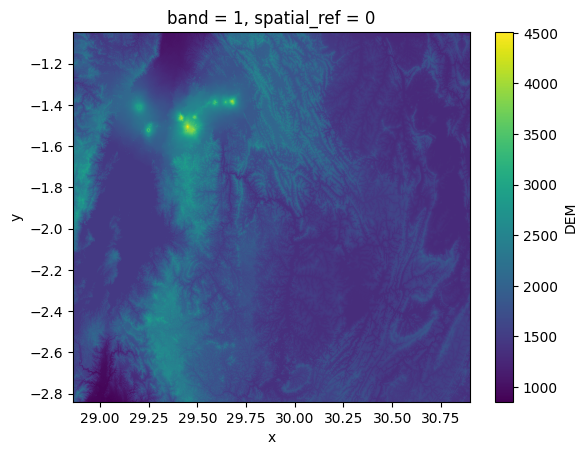

In [4]:
ds['band_data'].plot()